In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
import warnings
import time

from sklearn.model_selection import StratifiedKFold, train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (roc_auc_score, recall_score, brier_score_loss,
                             roc_curve, precision_recall_curve,
                             accuracy_score, precision_score, f1_score,
                             confusion_matrix)
%matplotlib inline
warnings.filterwarnings('ignore')

In [2]:

BASE_DIR = "../"
DATA_PATH = os.path.join(BASE_DIR, "data", "cancer_data_eng.csv")
IMG_DIR = os.path.join(BASE_DIR, "img")
RESULTS_DIR = os.path.join(BASE_DIR, "results")

os.makedirs(IMG_DIR, exist_ok=True)
os.makedirs(RESULTS_DIR, exist_ok=True)
RANDOM_STATE = 42
N_SAMPLES = 20000
N_JOBS = -1

In [3]:
print("\n[0] 加载数据...")
df = pd.read_csv(DATA_PATH, low_memory=False, encoding='latin-1')
df['target'] = df['Status.Vital'].map({'VIVO': 1, 'MORTO': 0})
df = df.dropna(subset=['target'])

np.random.seed(RANDOM_STATE)
if len(df) > N_SAMPLES:
    idx = np.random.choice(len(df), N_SAMPLES, replace=False)
    df = df.iloc[idx].copy()

print(f"    样本量: {len(df):,}")
print(f"    VIVO: {(df['target'] == 1).sum():,} ({(df['target'] == 1).mean()*100:.2f}%)")
print(f"    MORTO: {(df['target'] == 0).sum():,} ({(df['target'] == 0).mean()*100:.2f}%)")

# 特征准备
feature_cols = ['Age', 'year', 'Gender', 'Code.Profession', 'Code.of.Morphology',
                'Diagnostic.means', 'Extension', 'Raca.Color', 'State.Civil']
df_feat = df[feature_cols + ['target']].copy()

cat_cols = ['Gender', 'Diagnostic.means', 'Extension', 'Raca.Color', 'State.Civil']
for col in cat_cols:
    le = LabelEncoder()
    non_null = df_feat[col].dropna().astype(str)
    le.fit(non_null)
    mc = non_null.value_counts().index[0]
    def encode(x):
        if pd.isna(x): return np.nan
        xs = str(x)
        return le.transform([xs])[0] if xs in le.classes_ else le.transform([mc])[0]
    df_feat[col] = df_feat[col].apply(encode)

X = df_feat[feature_cols].astype(float).values
y = df_feat['target'].values

# 固定划分 (用于最终评估)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y)
print(f"    特征数: {len(feature_cols)}")
print(f"    训练集: {len(X_train):,}  测试集: {len(X_test):,}")


[0] 加载数据...
    样本量: 20,000
    VIVO: 8,230 (41.15%)
    MORTO: 11,770 (58.85%)
    特征数: 9
    训练集: 16,000  测试集: 4,000


In [4]:
def build_pipeline(model, scale_needed=True):
    """统一的 Pipeline 构建"""
    steps = []
    steps.append(('imputer', SimpleImputer(strategy='median')))
    if scale_needed:
        steps.append(('scaler', StandardScaler()))
    steps.append(('model', model))
    return Pipeline(steps)


def evaluate_model_cv(X, y, model_name, model, scale_needed=True, n_splits=5):
    """用 Stratified K-Fold 评估模型性能与稳定性"""
    cv = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=RANDOM_STATE)
    pipe = build_pipeline(model, scale_needed)

    aucs = []
    recalls = []
    briers = []
    times = []

    for fold_idx, (tr_idx, te_idx) in enumerate(cv.split(X, y)):
        X_tr, X_te = X[tr_idx], X[te_idx]
        y_tr, y_te = y[tr_idx], y[te_idx]

        start_t = time.time()
        pipe.fit(X_tr, y_tr)
        elapsed = time.time() - start_t

        if scale_needed and hasattr(pipe.named_steps.get('model'), 'decision_function'):
            # SVM: use decision_function for AUC
            try:
                y_score = pipe.decision_function(X_te)
                y_prob = 1 / (1 + np.exp(-y_score))
            except:
                y_pred = pipe.predict(X_te)
                y_prob = np.clip(y_pred.astype(float), 0, 1)
        else:
            try:
                y_prob = pipe.predict_proba(X_te)[:, 1]
            except:
                y_pred = pipe.predict(X_te)
                y_prob = np.clip(y_pred.astype(float), 0, 1)

        y_pred = (y_prob >= 0.5).astype(int)

        auc = roc_auc_score(y_te, y_prob)
        rec = recall_score(y_te, y_pred, pos_label=1)
        brier = brier_score_loss(y_te, y_prob)

        aucs.append(auc)
        recalls.append(rec)
        briers.append(brier)
        times.append(elapsed)

    return {
        'name': model_name,
        'auc_mean': np.mean(aucs),
        'auc_std': np.std(aucs),
        'recall_mean': np.mean(recalls),
        'recall_std': np.std(recalls),
        'brier_mean': np.mean(briers),
        'brier_std': np.std(briers),
        'time_mean': np.mean(times),
        'time_total': np.sum(times),
        'aucs': aucs,
        'recalls': recalls,
        'briers': briers,
    }

In [5]:
models = [
    ('Logistic Regression',
     LogisticRegression(class_weight='balanced', max_iter=5000,
                        random_state=RANDOM_STATE),
     True),
    ('SVM (Linear)',
     LinearSVC(class_weight='balanced', max_iter=5000, random_state=RANDOM_STATE,
               loss='hinge'),
     True),
    ('KNN (k=15)',
     KNeighborsClassifier(n_neighbors=15, n_jobs=N_JOBS),
     True),
    ('Decision Tree',
     DecisionTreeClassifier(class_weight='balanced', max_depth=10,
                            random_state=RANDOM_STATE),
     False),
    ('Random Forest',
     RandomForestClassifier(n_estimators=200, max_depth=12,
                            class_weight='balanced',
                            random_state=RANDOM_STATE, n_jobs=N_JOBS),
     False),
]

In [6]:
import xgboost as xgb
models.append((
    'XGBoost',
    xgb.XGBClassifier(
        n_estimators=300, max_depth=6, learning_rate=0.1,
        scale_pos_weight=(y == 0).sum() / (y == 1).sum(),
        random_state=RANDOM_STATE, n_jobs=N_JOBS, verbosity=0,
        eval_metric='logloss', use_label_encoder=False
    ),
    True  # XGBoost 对特征尺度不敏感, 标准化不影响性能
))

In [7]:
import lightgbm as lgb
models.append((
    'LightGBM',
    lgb.LGBMClassifier(
        n_estimators=300, max_depth=6, learning_rate=0.1,
        class_weight='balanced',
        random_state=RANDOM_STATE, n_jobs=N_JOBS, verbosity=-1
    ),
    True  # LightGBM 也对尺度不敏感
))

In [8]:
all_results = []

for name, model, scale_needed in models:
    print(f"\n  [{name}]  Stratified 5-Fold CV...", end=' ')
    result = evaluate_model_cv(X, y, name, model, scale_needed)
    all_results.append(result)
    print(f"done.")
    print(f"    AUC = {result['auc_mean']:.4f} ± {result['auc_std']:.4f}")
    print(f"    Recall = {result['recall_mean']:.4f} ± {result['recall_std']:.4f}")
    print(f"    Brier = {result['brier_mean']:.4f} ± {result['brier_std']:.4f}")
    print(f"    Time = {result['time_total']:.2f}s ({result['time_mean']:.2f}s/fold)")


  [Logistic Regression]  Stratified 5-Fold CV... done.
    AUC = 0.8936 ± 0.0033
    Recall = 0.8786 ± 0.0061
    Brier = 0.1310 ± 0.0020
    Time = 0.20s (0.04s/fold)

  [SVM (Linear)]  Stratified 5-Fold CV... done.
    AUC = 0.8946 ± 0.0033
    Recall = 0.8984 ± 0.0063
    Brier = 0.1347 ± 0.0015
    Time = 0.39s (0.08s/fold)

  [KNN (k=15)]  Stratified 5-Fold CV... done.
    AUC = 0.9110 ± 0.0013
    Recall = 0.8337 ± 0.0051
    Brier = 0.1186 ± 0.0009
    Time = 0.26s (0.05s/fold)

  [Decision Tree]  Stratified 5-Fold CV... done.
    AUC = 0.9151 ± 0.0018
    Recall = 0.8868 ± 0.0080
    Brier = 0.1144 ± 0.0021
    Time = 0.23s (0.05s/fold)

  [Random Forest]  Stratified 5-Fold CV... done.
    AUC = 0.9391 ± 0.0022
    Recall = 0.9050 ± 0.0067
    Brier = 0.1009 ± 0.0014
    Time = 3.25s (0.65s/fold)

  [XGBoost]  Stratified 5-Fold CV... done.
    AUC = 0.9421 ± 0.0019
    Recall = 0.8876 ± 0.0084
    Brier = 0.0977 ± 0.0015
    Time = 1.75s (0.35s/fold)

  [LightGBM]  Stratified 

  [图] 12a_model_performance.png


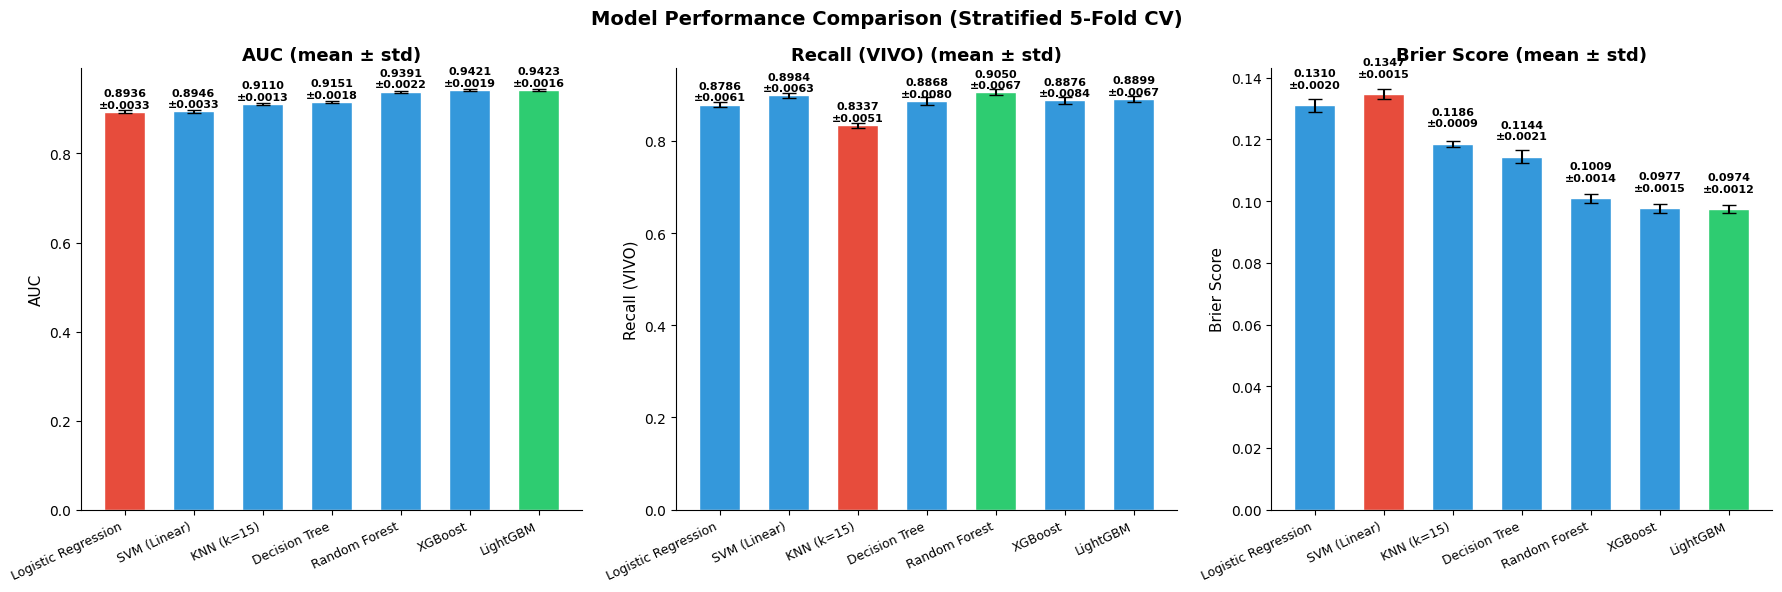

In [9]:
names = [r['name'] for r in all_results]

# ---------- 图 1: 性能条形图 (AUC + Recall + Brier) ----------
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
metrics = [
    ('auc_mean', 'auc_std', 'AUC', 'Score ↑', True),
    ('recall_mean', 'recall_std', 'Recall (VIVO)', 'Score ↑', True),
    ('brier_mean', 'brier_std', 'Brier Score', 'Score ↓', False),
]

for idx, (mean_key, std_key, title, _, higher_better) in enumerate(metrics):
    ax = axes[idx]
    means = [r[mean_key] for r in all_results]
    stds = [r[std_key] for r in all_results]

    colors = ['#2ecc71' if v == max(means) else '#e74c3c' if v == min(means) else '#3498db'
              for v in means] if higher_better else ['#2ecc71' if v == min(means) else '#e74c3c' if v == max(means) else '#3498db' for v in means]

    bars = ax.bar(range(len(names)), means, yerr=stds, color=colors,
                  edgecolor='white', capsize=5, width=0.6)
    ax.set_xticks(range(len(names)))
    ax.set_xticklabels(names, rotation=25, ha='right', fontsize=9)
    ax.set_ylabel(title, fontsize=11)
    ax.set_title(f'{title} (mean ± std)', fontsize=13, fontweight='bold')
    ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)

    for bar, mean, std in zip(bars, means, stds):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                f'{mean:.4f}\n±{std:.4f}',
                ha='center', va='bottom', fontsize=8, fontweight='bold')

plt.suptitle('Model Performance Comparison (Stratified 5-Fold CV)',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(IMG_DIR, "12a_model_performance.png"), dpi=150, bbox_inches='tight')
# plt.close()
print("  [图] 12a_model_performance.png")

  [图] 12b_stability_radar.png


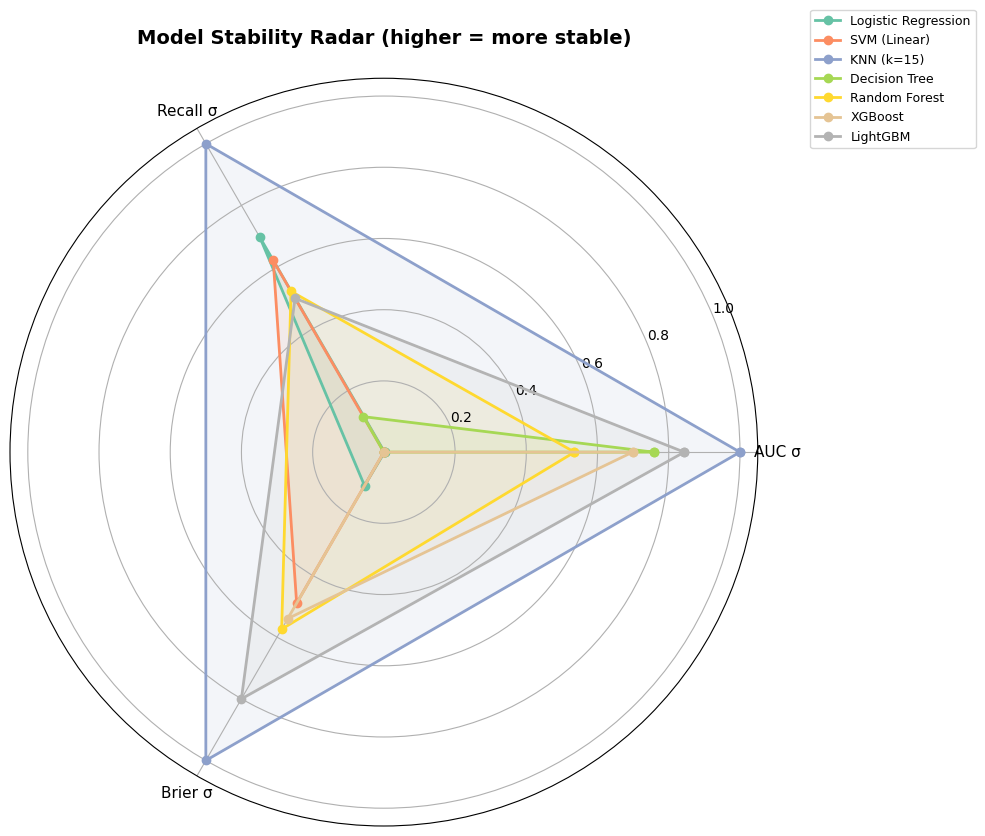

In [10]:
fig, ax = plt.subplots(figsize=(10, 10), subplot_kw=dict(polar=True))

metric_keys = ['auc_std', 'recall_std', 'brier_std']
metric_labels = ['AUC σ', 'Recall σ', 'Brier σ']
n_metrics = len(metric_keys)

# 标准化: 将 std 转化为稳定性分数 (0=最差, 1=最好)
stability_scores = {}
for key in metric_keys:
    vals = [r[key] for r in all_results]
    vmin, vmax = min(vals), max(vals)
    if vmax - vmin < 1e-8:
        stability_scores[key] = [1.0] * len(vals)
    else:
        stability_scores[key] = [(vmax - v) / (vmax - vmin) for v in vals]

angles = np.linspace(0, 2 * np.pi, n_metrics, endpoint=False).tolist()
angles += angles[:1]

colors_polar = plt.cm.Set2(np.linspace(0, 1, len(names)))
for i, name in enumerate(names):
    values = [stability_scores[k][i] for k in metric_keys]
    values += values[:1]
    ax.plot(angles, values, 'o-', linewidth=2, label=name, color=colors_polar[i])
    ax.fill(angles, values, alpha=0.1, color=colors_polar[i])

ax.set_xticks(angles[:-1])
ax.set_xticklabels(metric_labels, fontsize=11)
ax.set_ylim(0, 1.05)
ax.set_title('Model Stability Radar (higher = more stable)',
             fontsize=14, fontweight='bold', pad=25)
ax.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1), fontsize=9)
plt.tight_layout()
plt.savefig(os.path.join(IMG_DIR, "12b_stability_radar.png"), dpi=150, bbox_inches='tight')
# plt.close()
print("  [图] 12b_stability_radar.png")

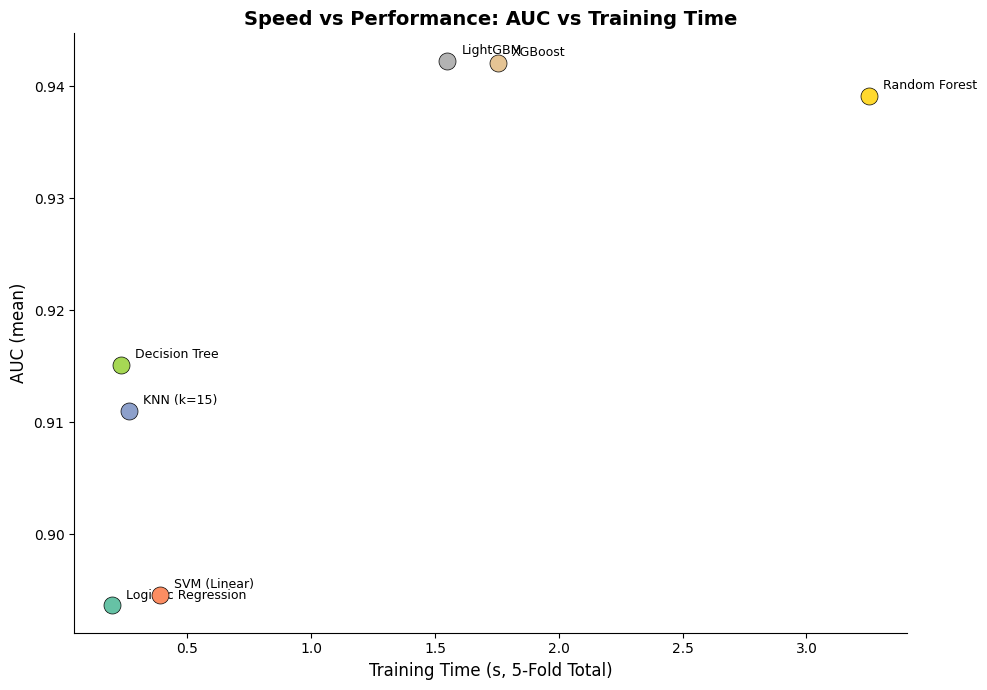

  [图] 12c_speed_vs_performance.png


In [11]:
fig, ax = plt.subplots(figsize=(10, 7))
for r in all_results:
    ax.scatter(r['time_total'], r['auc_mean'], s=150,
               c=colors_polar[names.index(r['name'])],
               edgecolors='black', linewidths=0.5, zorder=5)
    ax.annotate(r['name'], (r['time_total'], r['auc_mean']),
                textcoords='offset points', xytext=(10, 5), fontsize=9,
                ha='left')

ax.set_xlabel('Training Time (s, 5-Fold Total)', fontsize=12)
ax.set_ylabel('AUC (mean)', fontsize=12)
ax.set_title('Speed vs Performance: AUC vs Training Time',
             fontsize=14, fontweight='bold')
ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.savefig(os.path.join(IMG_DIR, "12c_speed_vs_performance.png"), dpi=150, bbox_inches='tight')
plt.show()
print("  [图] 12c_speed_vs_performance.png")

[图] 12c_changed_speed_vs_performance.png


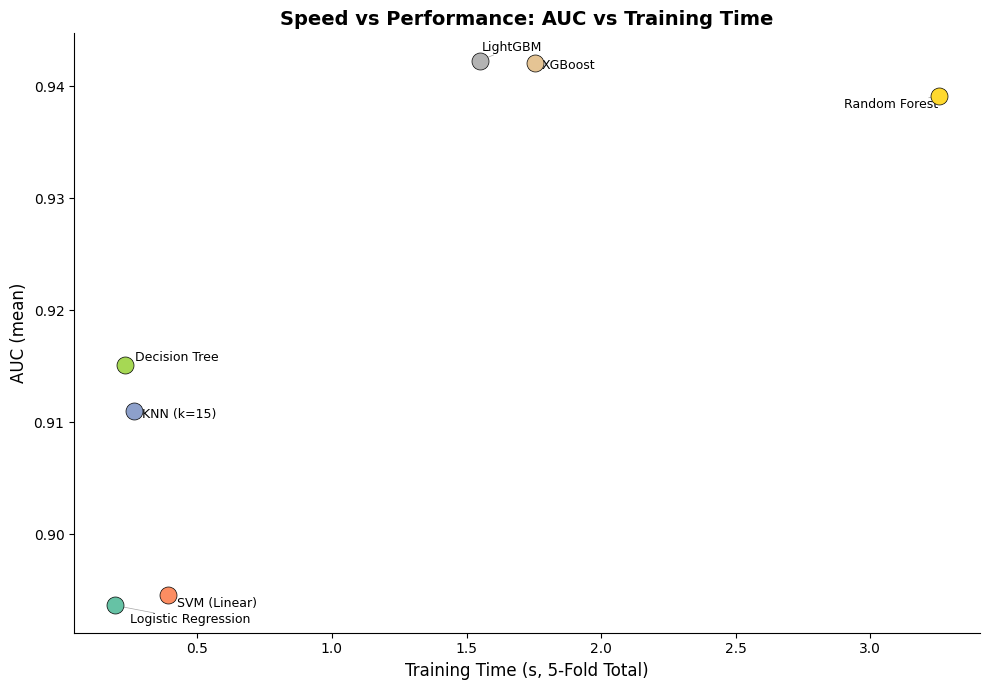

In [42]:
import matplotlib.pyplot as plt
from adjustText import adjust_text

fig, ax = plt.subplots(figsize=(10, 7))

# 创建一个空列表，用来存放生成的文字对象
texts = []

for r in all_results:
    # 画散点（保持你原本的样式：颜色、边缘黑线、高优先级 zorder）
    ax.scatter(r['time_total'], r['auc_mean'], 
               s=150, 
               c=colors_polar[names.index(r['name'])], 
               edgecolors='black', 
               linewidths=0.5, 
               zorder=5)

    # 核心改动：用 ax.text 生成文字，但不要指定偏移量，先让它呆在点的正上方
    t = ax.text(r['time_total'], r['auc_mean'], r['name'], 
                fontsize=9, 
                ha='left', 
                va='center')
    texts.append(t)  # 把文字对象存进列表

# 自动计算最合适的位置把文字推开，并画一条细灰线指回原点
adjust_text(
    texts, 
    force_text=0.02,
    only_move={'text': 'y', 'points': 'y'},  # 限制只在 Y 轴（上下）移动，防止 X 轴错乱
    arrowprops=dict(arrowstyle='-', color='gray', lw=0.5, alpha=0.7) ,
    avoid_self=True
)
# ===========================

# 设置坐标轴与标题
ax.set_xlabel('Training Time (s, 5-Fold Total)', fontsize=12)
ax.set_ylabel('AUC (mean)', fontsize=12)
ax.set_title('Speed vs Performance: AUC vs Training Time', fontsize=14, fontweight='bold')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig(os.path.join(IMG_DIR, "12c_speed_vs_performance.png"), dpi=150, bbox_inches='tight')
print("[图] 12c_changed_speed_vs_performance.png")
plt.show()

  [图] 12d_roc_curves.png


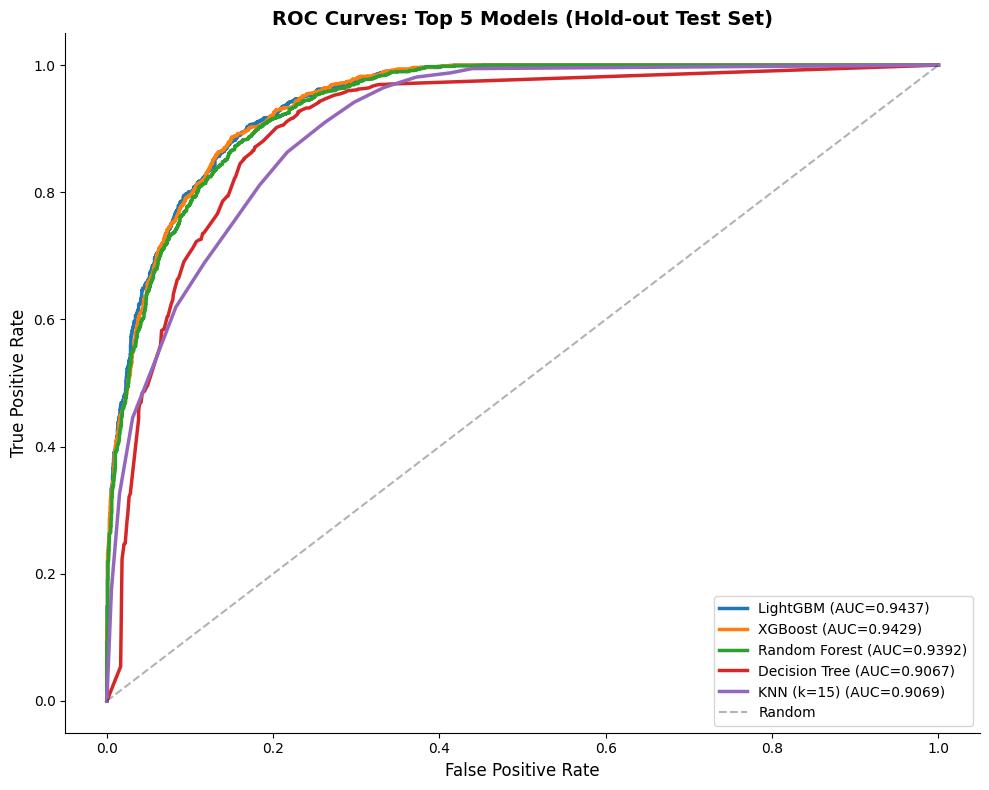

In [12]:
fig, ax = plt.subplots(figsize=(10, 8))

# 选出 AUC 最高的 5 个模型展示 ROC
sorted_results = sorted(all_results, key=lambda r: r['auc_mean'], reverse=True)
top5 = sorted_results[:5]

for r in top5:
    name = r['name']
    # 重建模型
    model_def = None
    for n, m, s in models:
        if n == name:
            model_def = (n, m, s)
            break
    if model_def is None:
        continue
    pipe = build_pipeline(model_def[1], model_def[2])
    pipe.fit(X_train, y_train)

    try:
        y_prob = pipe.predict_proba(X_test)[:, 1]
    except:
        try:
            y_score = pipe.decision_function(X_test)
            y_prob = 1 / (1 + np.exp(-y_score))
        except:
            y_pred = pipe.predict(X_test)
            y_prob = np.clip(y_pred.astype(float), 0, 1)

    fpr, tpr, _ = roc_curve(y_test, y_prob)
    auc = roc_auc_score(y_test, y_prob)
    ax.plot(fpr, tpr, linewidth=2.5, label=f'{name} (AUC={auc:.4f})')

ax.plot([0, 1], [0, 1], 'k--', alpha=0.3, label='Random')
ax.set_xlabel('False Positive Rate', fontsize=12)
ax.set_ylabel('True Positive Rate', fontsize=12)
ax.set_title('ROC Curves: Top 5 Models (Hold-out Test Set)',
             fontsize=14, fontweight='bold')
ax.legend(fontsize=10, loc='lower right')
ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.savefig(os.path.join(IMG_DIR, "12d_roc_curves.png"), dpi=150, bbox_inches='tight')
# plt.close()
print("  [图] 12d_roc_curves.png")

  [图] 12e_pr_curves.png


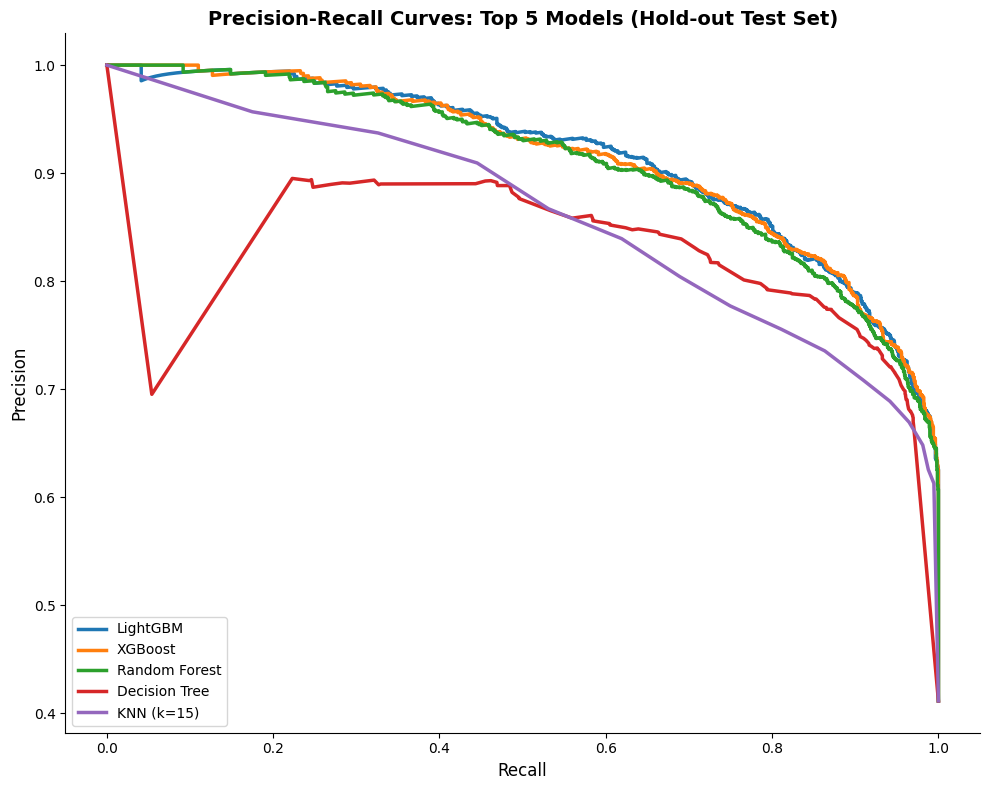

In [13]:
fig, ax = plt.subplots(figsize=(10, 8))
for r in top5:
    name = r['name']
    model_def = None
    for n, m, s in models:
        if n == name:
            model_def = (n, m, s)
            break
    if model_def is None:
        continue
    pipe = build_pipeline(model_def[1], model_def[2])
    pipe.fit(X_train, y_train)

    try:
        y_prob = pipe.predict_proba(X_test)[:, 1]
    except:
        try:
            y_score = pipe.decision_function(X_test)
            y_prob = 1 / (1 + np.exp(-y_score))
        except:
            y_pred = pipe.predict(X_test)
            y_prob = np.clip(y_pred.astype(float), 0, 1)

    prec, rec, _ = precision_recall_curve(y_test, y_prob)
    ax.plot(rec, prec, linewidth=2.5, label=name)

ax.set_xlabel('Recall', fontsize=12)
ax.set_ylabel('Precision', fontsize=12)
ax.set_title('Precision-Recall Curves: Top 5 Models (Hold-out Test Set)',
             fontsize=14, fontweight='bold')
ax.legend(fontsize=10, loc='lower left')
ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.savefig(os.path.join(IMG_DIR, "12e_pr_curves.png"), dpi=150, bbox_inches='tight')
# plt.close()
print("  [图] 12e_pr_curves.png")

  [图] 12f_fold_variance.png


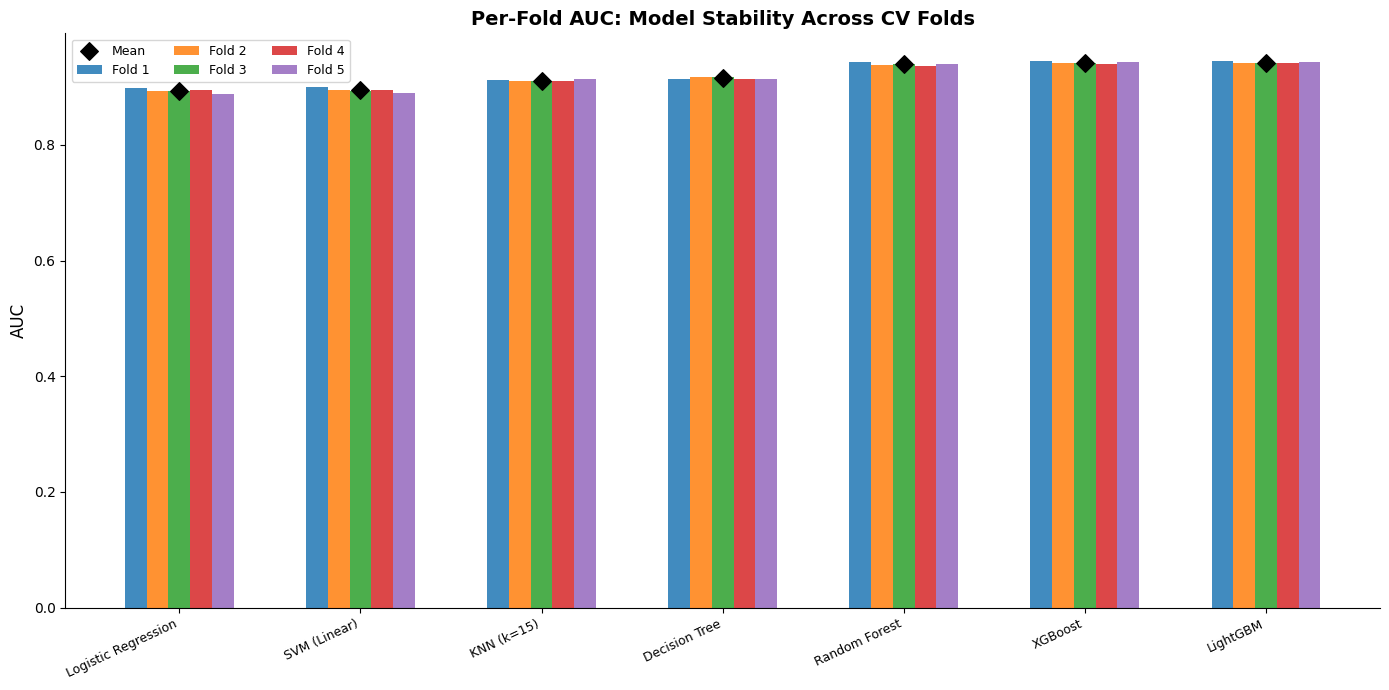

In [14]:
fig, ax = plt.subplots(figsize=(14, 7))
x_pos = np.arange(len(names))
width = 0.12

for fold_i in range(5):
    fold_aucs = [r['aucs'][fold_i] for r in all_results]
    offset = (fold_i - 2) * width
    bars = ax.bar(x_pos + offset, fold_aucs, width,
                  label=f'Fold {fold_i+1}', alpha=0.85)

# Overlay mean
mean_aucs = [r['auc_mean'] for r in all_results]
ax.scatter(x_pos, mean_aucs, color='black', s=80, marker='D',
           zorder=10, label='Mean')

ax.set_xticks(x_pos)
ax.set_xticklabels(names, rotation=25, ha='right', fontsize=9)
ax.set_ylabel('AUC', fontsize=12)
ax.set_title('Per-Fold AUC: Model Stability Across CV Folds',
             fontsize=14, fontweight='bold')
ax.legend(fontsize=9, ncol=3)
ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.savefig(os.path.join(IMG_DIR, "12f_fold_variance.png"), dpi=150, bbox_inches='tight')
# plt.close()
print("  [图] 12f_fold_variance.png")